# Importing Libraries  

In [14]:
import os
import math
import random
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scipy
import numpy as np
import pandas as pd

# Question and Hypotesis of this notebook
Does the day of the week affect cleanliness ratings and overall guest satisfaction on Airbnb?

Hypothesis: Airbnb listings will have lower cleanliness ratings and guest satisfaction scores on weekends compared to weekdays, due to higher turnover and less time for cleaning between stays.

# Importing Dataframes

In [2]:
airbnb_weekdays = pd.read_pickle('../01. Data/02. Clean Data/airbnb_paris_weekdays_cleaned.pkl')

In [3]:
airbnb_weekends = pd.read_pickle('../01. Data/02. Clean Data/airbnb_paris_weekend_cleaned.pkl')

In [6]:
airbnb_weekdays.shape, airbnb_weekends.shape

((3130, 12), (3558, 12))

In [15]:
# defining color palette for the visualizations
palette = {
  "navy": "#1a1a2e",
  "amber": "#E8A020",
  "amber_dark": "#BA7517",
  "amber_light": "#FAEEDA",
  "blue": "#185FA5",
  "teal": "#5DCAA5",
  "gray": "#888780"
}

# Analysing focusing on Question/Hypotesis

In [4]:
# concatenating both airbnb dataframes to use for the analysis
airbnb_combined = pd.concat(
    [airbnb_weekdays, airbnb_weekends],
    ignore_index=True
).copy()

print("Airbnb combined shape:", airbnb_combined.shape)
display(airbnb_combined.head())

Airbnb combined shape: (6688, 12)


,type_of_day,cost_2pax_2night,cost_2pax_1night,room_type,bedrooms,person_capacity,host_is_superhost,cleanliness_rating,guest_satisfaction_overall,longitude,latitude,distance_km
0,weekday,296.159940,148.079970,Private room,1,2.0,True,10.0,97.0,2.35385,48.86282,0.699821
1,weekday,288.237487,144.118744,Private room,1,2.0,True,10.0,97.0,2.32436,48.85902,2.100005
2,weekday,211.343089,105.671544,Private room,1,2.0,False,10.0,94.0,2.31714,48.87475,3.302325
3,weekday,298.956100,149.478050,Entire home/apt,1,2.0,False,9.0,91.0,2.35600,48.86100,0.547567
4,weekday,247.926181,123.963091,Entire home/apt,1,4.0,False,7.0,82.0,2.35915,48.86648,1.197921


In [8]:
# exporting the cleaned dataframe before proceeding with analysis
airbnb_combined.to_pickle('../01. Data/02. Clean Data/airbnb_paris_combined_cleaned.pkl')

In [25]:
# checking decribtive statistics for cleanliness rating for both weekdays and weekends
cleanliness_stats = airbnb_combined.groupby('type_of_day')['cleanliness_rating'].describe()
cleanliness_stats

,count,mean,std,min,25%,50%,75%,max
type_of_day,,,,,,,,
weekday,3130.0,9.253994,0.987793,2.0,9.0,9.0,10.0,10.0
weekend,3558.0,9.272063,0.961830,2.0,9.0,9.0,10.0,10.0


The average of the clealiness is very close, with the weekend being a bit lower than the weekend. This makes sense, as usually weekends are rented out and the time to do the cleaning is during the week, in which we have less bookings (and therefore, more time to clean in between rentals)

In [ ]:
# checking the distribution of cleanliness ratings
airbnb_combined['cleanliness_rating'].value_counts()

cleanliness_rating
10.0    3324
9.0     2341
8.0      704
7.0      198
6.0       85
4.0       17
2.0       15
5.0        4
Name: count, dtype: int64

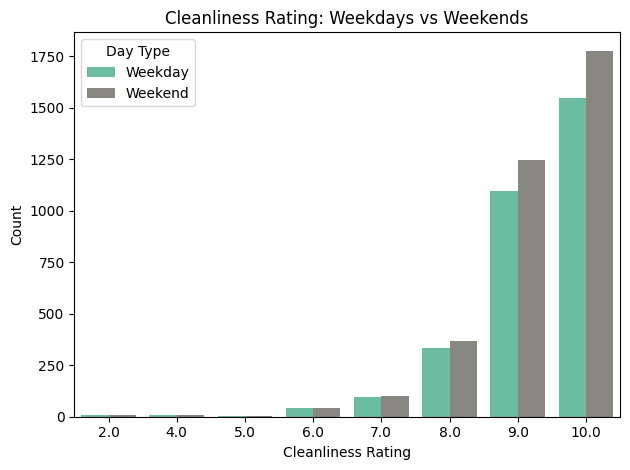

In [37]:
# creating the barplot to compare the distribution of cleanliness ratings between weekdays and weekends
cleanliness_bar = sns.countplot(data=airbnb_combined, x='cleanliness_rating', hue='type_of_day', palette={'weekday': palette['teal'], 'weekend': palette['gray']})

plt.title('Cleanliness Rating: Weekdays vs Weekends')
plt.xlabel('Cleanliness Rating')
plt.ylabel('Count')

plt.legend(title='Day Type', labels=['Weekday', 'Weekend'])
plt.tight_layout()
plt.show()

In [38]:
# exporting the barpltot   
cleanliness_bar.figure.savefig('../03. Visualizations/cleanliness_rating_comparison.png', dpi=300)

In [ ]:
# checking decribtive statistics for guest satisfaction for both weekdays and weekends
guest_satisfaction_stats = airbnb_combined.groupby('type_of_day')['guest_satisfaction_overall'].describe()
guest_satisfaction_stats

,count,mean,std,min,25%,50%,75%,max
type_of_day,,,,,,,,
weekday,3130.0,91.851438,8.996678,20.0,89.0,94.0,98.0,100.0
weekend,3558.0,92.201237,8.656113,20.0,89.0,94.0,98.0,100.0


In [40]:
# creating buckets for guest satisfaction ratings
airbnb_combined['satisfaction_bucket'] = pd.cut(
    airbnb_combined['guest_satisfaction_overall'], 
    bins=range(0, 101, 10),  # buckets of 10: 0-10, 10-20, etc.
    right=True
)

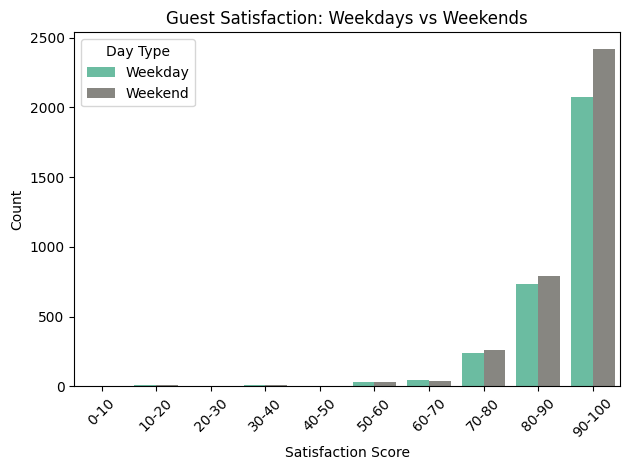

In [43]:
# creating the barplot to compare the distribution of guest satisfaction between weekdays and weekends
guest_satisfaction_bar = sns.countplot(data=airbnb_combined, x='satisfaction_bucket', hue='type_of_day', palette={'weekday': palette['teal'], 'weekend': palette['gray']})

plt.title('Guest Satisfaction: Weekdays vs Weekends')
plt.xlabel('Satisfaction Score')
plt.ylabel('Count')

plt.legend(title='Day Type', labels=['Weekday', 'Weekend'])

bucket_labels = ['0-10', '10-20', '20-30', '30-40', '40-50', 
                 '50-60', '60-70', '70-80', '80-90', '90-100']
plt.xticks(range(len(bucket_labels)), bucket_labels, rotation=45)

plt.tight_layout()
plt.show()


In [44]:
# exporting the barpltot   
guest_satisfaction_bar.figure.savefig('../03. Visualizations/guest_satisfaction_comparison.png', dpi=300)

In [23]:
# checking decribtive statistics for the price column for both weekdays and weekends
price_stats = airbnb_combined.groupby('type_of_day')['cost_2pax_1night'].describe()
price_stats

,count,mean,std,min,25%,50%,75%,max
type_of_day,,,,,,,,
weekday,3130.0,199.393339,198.183992,46.369652,120.001864,159.264610,231.731755,8222.807345
weekend,3558.0,193.514295,130.037550,47.651226,120.497017,158.099543,230.566688,2094.207289


In [46]:
# creating buckets for price ratings
airbnb_combined['price_bucket'] = pd.cut(
    airbnb_combined['cost_2pax_1night'], 
    bins=range(0, 501, 50),  # buckets of 50: 0-50, 50-100, etc.
    right=True
)

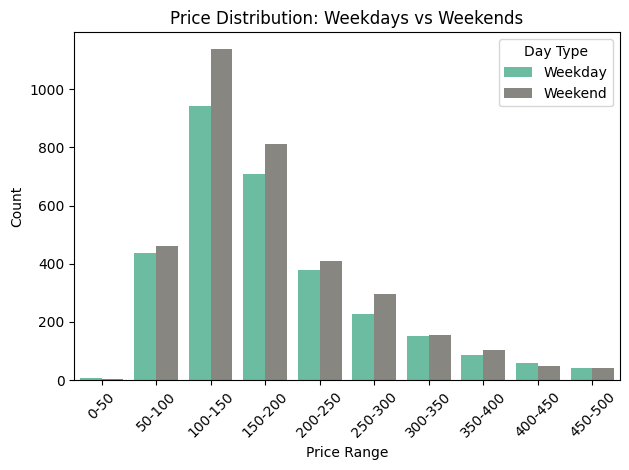

In [49]:
# creating the barplot to compare the distribution of prices between weekdays and weekends
price_bar = sns.countplot(data=airbnb_combined, x='price_bucket', hue='type_of_day', palette={'weekday': palette['teal'], 'weekend': palette['gray']})

plt.title('Price Distribution: Weekdays vs Weekends')
plt.xlabel('Price Range')
plt.ylabel('Count')

plt.legend(title='Day Type', labels=['Weekday', 'Weekend'])

bucket_labels = ['0-50', '50-100', '100-150', '150-200', '200-250', 
                 '250-300', '300-350', '350-400', '400-450', '450-500']
plt.xticks(range(len(bucket_labels)), bucket_labels, rotation=45)

plt.tight_layout()
plt.show()

In [50]:
# exporting the barpltot   
price_bar.figure.savefig('../03. Visualizations/price_distribution_comparison.png', dpi=300)